## Import Libraries..

In [2]:
# libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library for apply mathmatical operations
from math import radians, sin, cos, sqrt, atan2

# library to split data
from sklearn.model_selection import train_test_split

# Library for data scalling
from sklearn.preprocessing import StandardScaler

# library to build model for prediction
from sklearn.linear_model import LinearRegression

# library to get different metric score
from sklearn.metrics import r2_score, mean_squared_error

# library to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Load Dataset..

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/nyc_taxi_trip_duration.csv")

## Data Overview..

In [5]:
data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [6]:
data.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
729317,id3905982,2,21-05-2016 13:29,21-05-2016 13:34,2,-73.965919,40.789780,-73.952637,40.789181,N,296
729318,id0102861,1,22-02-2016 00:43,22-02-2016 00:48,1,-73.996666,40.737434,-74.001320,40.731911,N,315
729319,id0439699,1,15-04-2016 18:56,15-04-2016 19:08,1,-73.997849,40.761696,-74.001488,40.741207,N,673
729320,id2078912,1,19-06-2016 09:50,19-06-2016 09:58,1,-74.006706,40.708244,-74.013550,40.713814,N,447
729321,id1053441,2,01-01-2016 17:24,01-01-2016 17:44,4,-74.003342,40.743839,-73.945847,40.712841,N,1224


In [7]:
data.shape

(729322, 11)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [9]:
data.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712235,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


## Drop Irrelevent Columns..

In [10]:
data.drop(["id", "dropoff_datetime"], axis = 1, inplace = True)
print("Remaining Columns:", data.columns.tolist())

Remaining Columns: ['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


## Checking Missing Values..

In [11]:
data.isnull().sum()

,0
vendor_id,0
pickup_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0
trip_duration,0


## Check Duplicate Values..

In [12]:
data.duplicated().sum()

np.int64(0)

## Feature Engineering..

In [13]:
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])

In [14]:
data["pickup_hour"] = data["pickup_datetime"].dt.hour
data["pickup_day"] = data["pickup_datetime"].dt.dayofweek
data["pickup_month"] = data["pickup_datetime"].dt.month
data["is_weekend"] = data["pickup_day"].apply(lambda x: 1 if x >= 5 else 0)

In [15]:
data.drop("pickup_datetime", axis=1, inplace = True)

In [16]:
print(data[["pickup_hour","pickup_day","pickup_month","is_weekend"]].head())

   pickup_hour  pickup_day  pickup_month  is_weekend
0           16           0             2           0
1           23           4             3           0
2           17           6             2           1
3            9           1             1           0
4            6           2             2           0


In [17]:
def haversine(lat1, lon1, lat2, lon2):
  R = 6371
  lat1, lon1, lat2, lon2 = map(radians,[lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
  return R * 2 * atan2(sqrt(a), sqrt(1-a))

In [18]:
data["distance_km"] = data.apply(
    lambda row: haversine(
        row["pickup_latitude"], row["pickup_longitude"],
        row["dropoff_latitude"], row["dropoff_longitude"]), axis = 1
)

In [19]:
data["distance_km"].describe()

,distance_km
count,729322.000000
mean,3.441139
std,4.353132
min,0.000000
25%,1.232695
50%,2.095672
75%,3.876482
max,1240.908676



## Exploratory Data Analysis (EDA)..

**Histplot :-**
1. Trip Duration Distribution
2. Log Trip Duration Distribution  
3. Distance (km) Distribution
4. Passenger Count Distribution

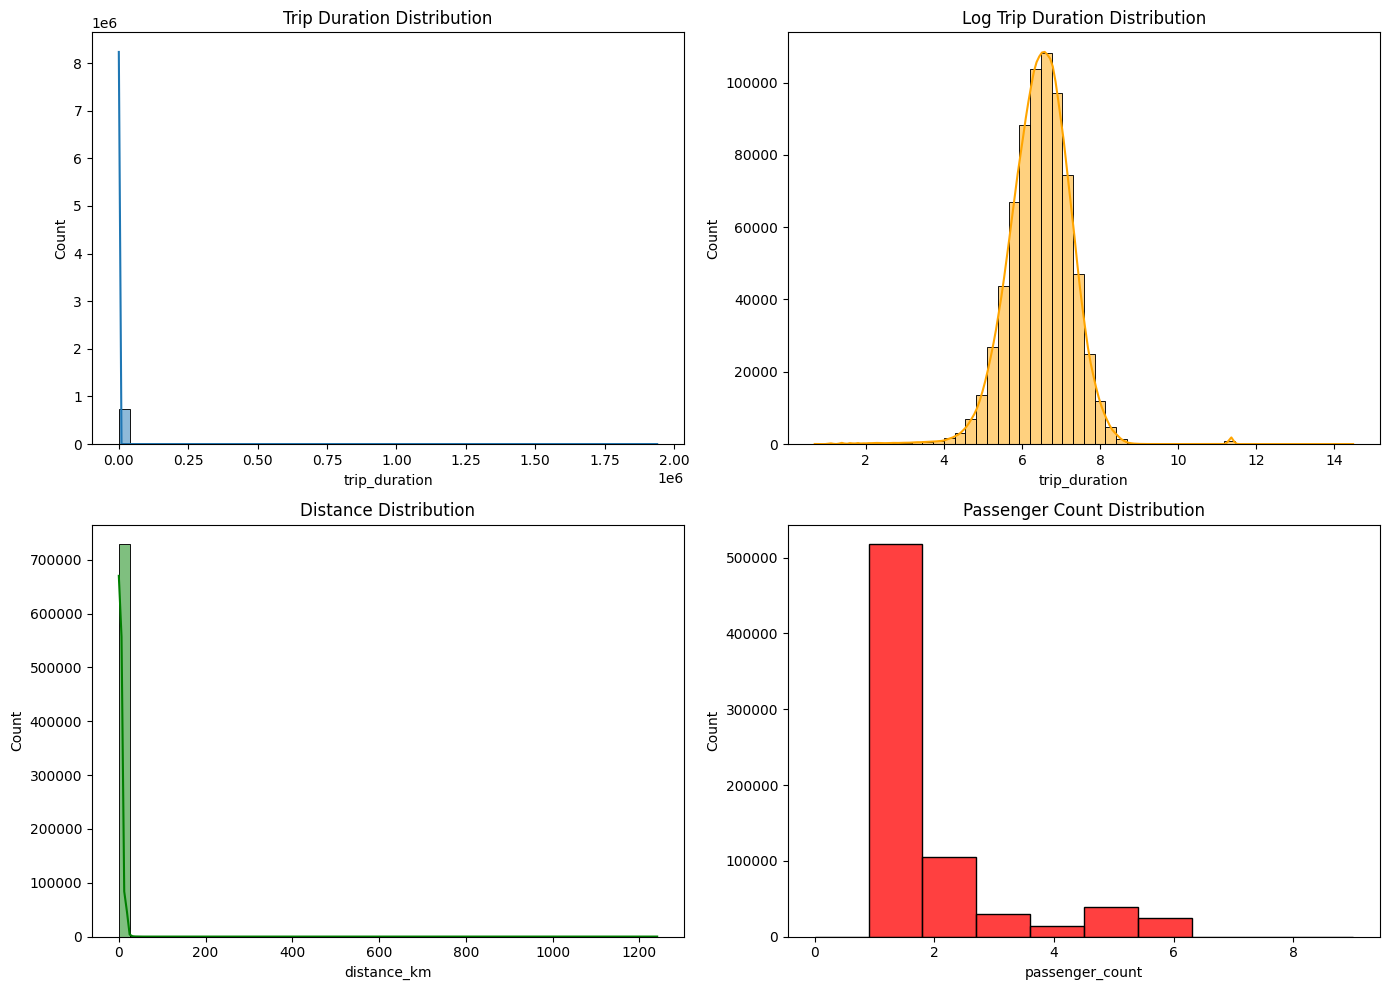

In [20]:
fig, axes = plt.subplots(2,2,figsize = (14,10))

# Trip Duration
sns.histplot(data["trip_duration"], bins = 50,
             kde = True, ax=axes[0,0])
axes[0,0].set_title("Trip Duration Distribution")

# Log Trip Duration
sns.histplot(np.log1p(data["trip_duration"]), bins = 50,
             kde = True, ax=axes[0,1], color="orange")
axes[0,1].set_title("Log Trip Duration Distribution")

# Distance
sns.histplot(data["distance_km"], bins=50,
             kde = True, ax=axes[1,0], color="green")
axes[1,0].set_title("Distance Distribution")

# Passenger Count
sns.histplot(data["passenger_count"], bins=10,
             kde=False, ax=axes[1,1], color="red")
axes[1,1].set_title("Passenger Count Distribution")

plt.tight_layout()
plt.show()

**Scatter Plot :-**
1. Distance vs Trip Duration
2. Pickup Locations (Longitude vs Latitude)
3. Dropoff Locations (Longitude vs Latitude)

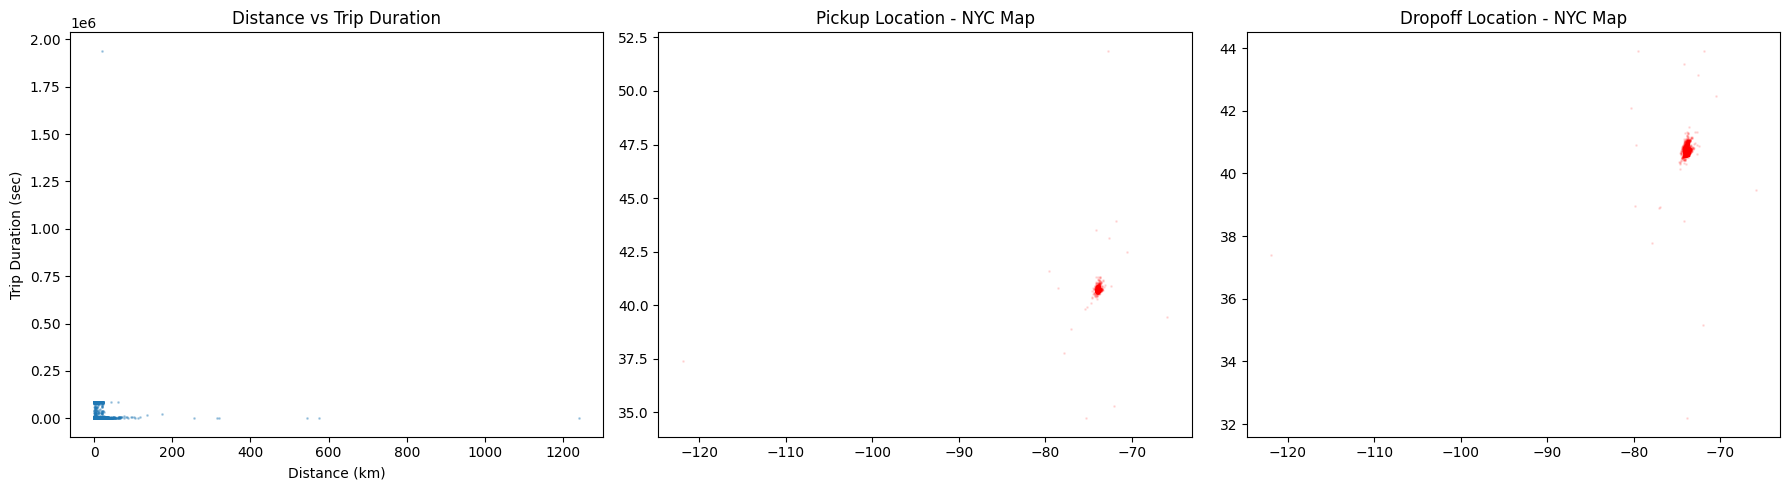

In [21]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

# Distance vs Trip Duration
axes[0].scatter(data["distance_km"],
                data["trip_duration"], alpha=0.3, s=1)
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Trip Duration (sec)")
axes[0].set_title("Distance vs Trip Duration")

# Pickup Locations
axes[1].scatter(data["pickup_longitude"],
                data["pickup_latitude"], alpha=0.1, s=1, c="red")
axes[1].set_title("Pickup Location - NYC Map")

# Dropoff Locations
axes[2].scatter(data["dropoff_longitude"],
                data["dropoff_latitude"], alpha=0.1, s=1, c="red")
axes[2].set_title("Dropoff Location - NYC Map")

plt.tight_layout()
plt.show()

**Bar Plot :-**
1. Vendor ID vs Avg Trip Duration
2. Passenger Count vs Avg Trip Duration
3. Pickup Hour vs Avg Trip Duration
4. Day of Week vs Trip Count
5. Month vs Avg Trip Duration
6. Store and Forward Flag — Count

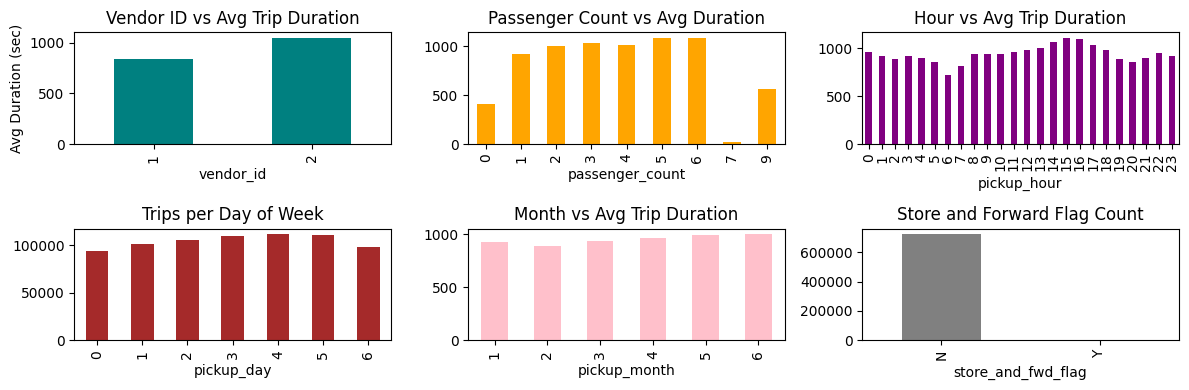

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Vendor ID vs Avg Trip Duration
data.groupby('vendor_id')['trip_duration'].mean()\
    .plot(kind='bar', ax=axes[0,0], color='teal')
axes[0,0].set_title('Vendor ID vs Avg Trip Duration')
axes[0,0].set_ylabel('Avg Duration (sec)')

# Passenger Count vs Avg Trip Duration
data.groupby('passenger_count')['trip_duration'].mean()\
    .plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Passenger Count vs Avg Duration')

# Hour of Day vs Avg Trip Duration
data.groupby('pickup_hour')['trip_duration'].mean()\
    .plot(kind='bar', ax=axes[0,2],
          figsize=(12,4), color='purple')
axes[0,2].set_title('Hour vs Avg Trip Duration')

# Day of Week vs Trip Count
data['pickup_day'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[1,0], color='brown')
axes[1,0].set_title('Trips per Day of Week')

# Month vs Avg Trip Duration
data.groupby('pickup_month')['trip_duration'].mean()\
    .plot(kind='bar', ax=axes[1,1], color='pink')
axes[1,1].set_title('Month vs Avg Trip Duration')

# Store and Fwd Flag
data['store_and_fwd_flag'].value_counts()\
    .plot(kind='bar', ax=axes[1,2], color='gray')
axes[1,2].set_title('Store and Forward Flag Count')

plt.tight_layout()
plt.show()

## Outliers Detection and Removal..

**Statistical Summary :-**

In [23]:
cols_to_check = ["trip_duration", "distance_km", "passenger_count"]

for col in cols_to_check:
  print(f"\n{"="*40}\n")
  print(f"Column: {col}")
  print(data[col].describe(
      percentiles = [.01,.05,.25,.50,.75,.95,.99]
  ))
print(f"\n{"="*40}\n")



Column: trip_duration
count    7.293220e+05
mean     9.522291e+02
std      3.864626e+03
min      1.000000e+00
1%       8.700000e+01
5%       1.800000e+02
25%      3.970000e+02
50%      6.630000e+02
75%      1.075000e+03
95%      2.102000e+03
99%      3.429000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64


Column: distance_km
count    729322.000000
mean          3.441139
std           4.353132
min           0.000000
1%            0.142009
5%            0.595876
25%           1.232695
50%           2.095672
75%           3.876482
95%          10.993392
99%          20.769756
max        1240.908676
Name: distance_km, dtype: float64


Column: passenger_count
count    729322.000000
mean          1.662055
std           1.312446
min           0.000000
1%            1.000000
5%            1.000000
25%           1.000000
50%           1.000000
75%           2.000000
95%           5.000000
99%           6.000000
max           9.000000
Name: passenger_count, dtype: float64




**Visualize Outliers (Histogram + Boxplot) :-**

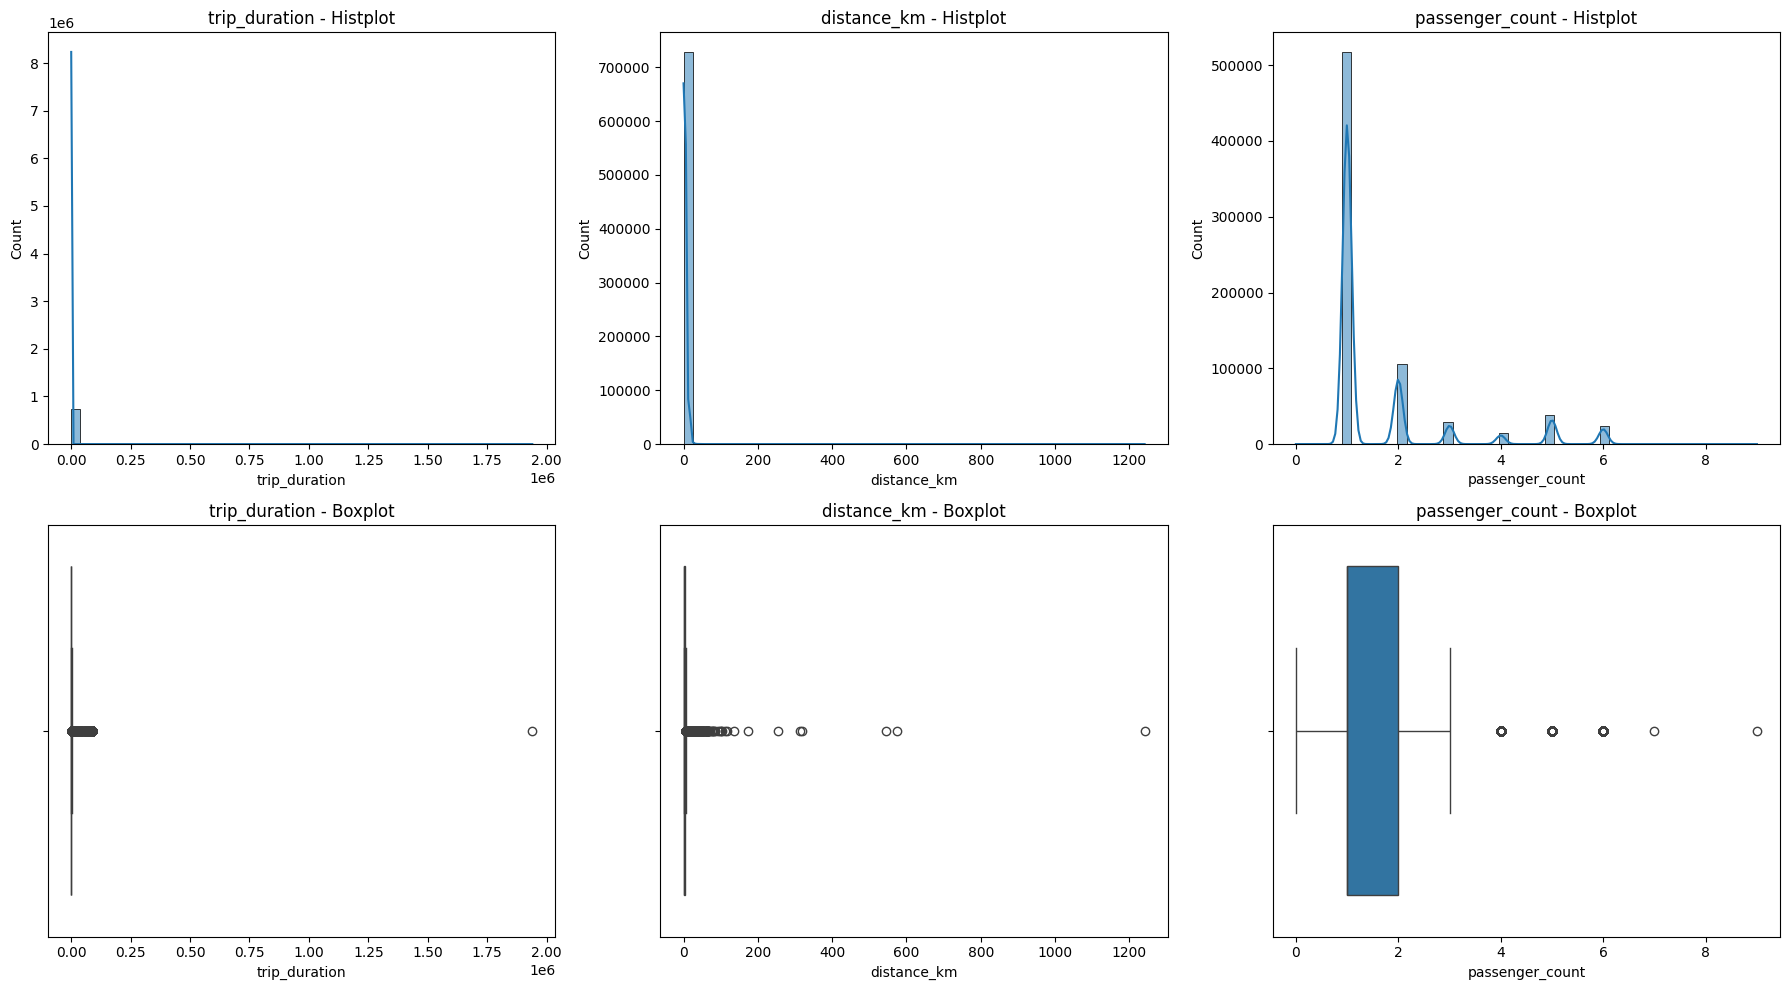

In [24]:
fig, axes = plt.subplots(2,3,figsize=(18,10))

for i, col in enumerate(cols_to_check):
  # Histplot
  sns.histplot(data[col], bins=50, kde=True,
               ax=axes[0,i])
  axes[0,i].set_title(f"{col} - Histplot")

  # Boxplot
  sns.boxplot(x = data[col], ax=axes[1,i])
  axes[1,i].set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()

**Calculate IQR Bounds :-**

In [25]:
for col in cols_to_check:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)

  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = data[(data[col] < lower) | (data[col] > upper)]

  print(f"{col}:")
  print(f" Lower Bound : {lower:.2f}")
  print(f" Upper Bound : {upper:.2f}")
  print(f" Outliers : {len(outliers)}")
  print()

trip_duration:
 Lower Bound : -620.00
 Upper Bound : 2092.00
 Outliers : 36963

distance_km:
 Lower Bound : -2.73
 Upper Bound : 7.84
 Outliers : 70318

passenger_count:
 Lower Bound : -0.50
 Upper Bound : 3.50
 Outliers : 77085



**Remove Outliers :-**

In [26]:
# Trip Duration
Q1 = data["trip_duration"].quantile(0.25)
Q3 = data["trip_duration"].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data = data[(data["trip_duration"] >= lower) &
            (data["trip_duration"] <= upper)]

# Distance
Q1 = data["distance_km"].quantile(0.25)
Q3 = data["distance_km"].quantile(0.75)
IQR = Q3-Q1
lower = 0
upper = Q3 + 1.5 * IQR
data = data[(data["distance_km"] > lower) &
            (data["distance_km"] <= upper)]

# Passenger Count -
print(data["passenger_count"].value_counts())
data = data[(data["passenger_count"] > 0) &
            (data["passenger_count"] <= 6)]

# NYC Coordinates - domain knowledge
data = data[
    (data["pickup_longitude"].between(-74.05,-73.75)) &
    (data["pickup_latitude"].between(40.63,40.85)) &
    (data["dropoff_longitude"].between(-74.05,-73.75)) &
    (data["dropoff_latitude"].between(40.63,4085))
]


passenger_count
1    453011
2     90231
5     33725
3     25767
6     20924
4     12132
0        21
7         1
Name: count, dtype: int64


**Verify Shape After Removal :-**

In [27]:
print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (634973, 13)


## Encoding Categorical Variables..

In [28]:
# Store_and_fwd_flag - 0/1
data["store_and_fwd_flag"] = data["store_and_fwd_flag"].map({"N":0, "Y":1})
print(data["store_and_fwd_flag"].value_counts())

store_and_fwd_flag
0    631957
1      3016
Name: count, dtype: int64


## Log Transformation of Target Variable..

In [29]:
# Checking Skewness
print("Skewness before:", data["trip_duration"].skew())

data["log_trip_duration"] = np.log1p(data["trip_duration"])

print("Skewness after:", data["log_trip_duration"].skew())

Skewness before: 0.9269844021265505
Skewness after: -0.9379517856697874


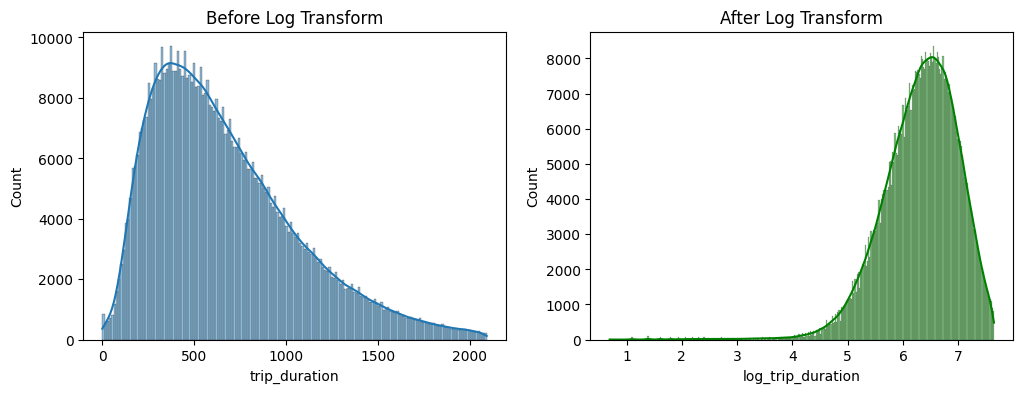

In [30]:
# Comparision plot
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data["trip_duration"],
             kde=True, ax=axes[0])
axes[0].set_title("Before Log Transform")

sns.histplot(data["log_trip_duration"],
             kde=True, ax=axes[1], color="green")
axes[1].set_title("After Log Transform")
plt.show()

## Correlation Analysis..

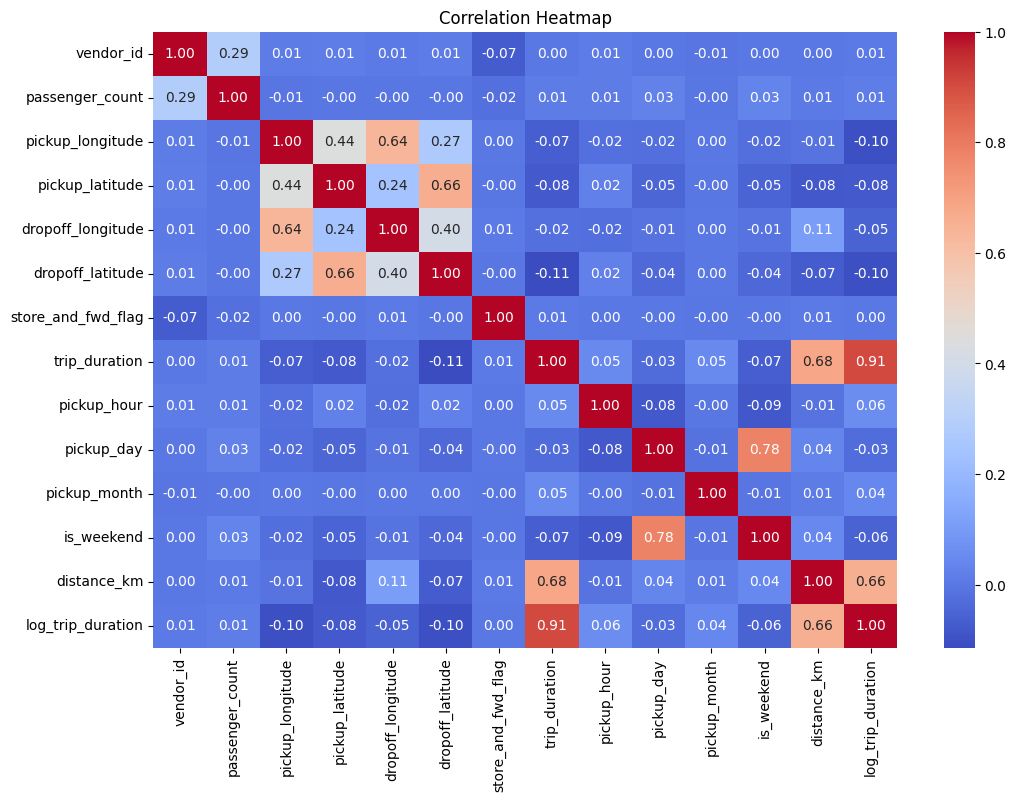

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,
            fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# Top correlations with target
print(data.corr()["log_trip_duration"].sort_values(ascending=False))

log_trip_duration     1.000000
trip_duration         0.908615
distance_km           0.659448
pickup_hour           0.056654
pickup_month          0.039569
passenger_count       0.013744
vendor_id             0.005559
store_and_fwd_flag    0.003432
pickup_day           -0.029769
dropoff_longitude    -0.053418
is_weekend           -0.056792
pickup_latitude      -0.076282
dropoff_latitude     -0.100546
pickup_longitude     -0.101124
Name: log_trip_duration, dtype: float64


## Train-Test Split..

In [33]:
X = data.drop(["trip_duration","log_trip_duration"], axis=1)
y = data["log_trip_duration"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'distance_km']
X shape: (634973, 12)
y shape: (634973,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (507978, 12)
Test size: (126995, 12)


## Feature Scaling..

In [35]:
scaler = StandardScaler()

# fit_transform for train data
X_train_sc = scaler.fit_transform(X_train)

# Only for transform test
X_test_sc = scaler.transform(X_test)

## Model Training..

In [36]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

LinearRegression()

In [37]:
print("Intercept:", model.intercept_)
print("\nFeature Coefficients:\n")
for feat, coef in zip(X.columns, model.coef_):
  print(f" {feat:25s}: {coef:.4f}")

Intercept: 6.3165174774674755

Feature Coefficients:

 vendor_id                : 0.0014
 passenger_count          : 0.0074
 pickup_longitude         : -0.0316
 pickup_latitude          : 0.0259
 dropoff_longitude        : -0.0612
 dropoff_latitude         : -0.0216
 store_and_fwd_flag       : -0.0001
 pickup_hour              : 0.0360
 pickup_day               : 0.0237
 pickup_month             : 0.0215
 is_weekend               : -0.0746
 distance_km              : 0.4552


## Model Prediction..

In [38]:
y_pred = model.predict(X_test_sc)

## Model Evaluation..

In [39]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))

print(f"R² Score : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")

R² Score : 0.4654
RMSE : 0.4944
MAE : 0.3739


In [40]:
# Original scale pe bhi dekho
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)
rmse_actual = np.sqrt(mean_squared_error(
                  y_test_actual, y_pred_actual))
print(f"\nRMSE (seconds): {rmse_actual:.2f}")
print(f"RMSE (minutes): {rmse_actual/60:.2f}")


RMSE (seconds): 329.25
RMSE (minutes): 5.49


## Evaluation Plots..

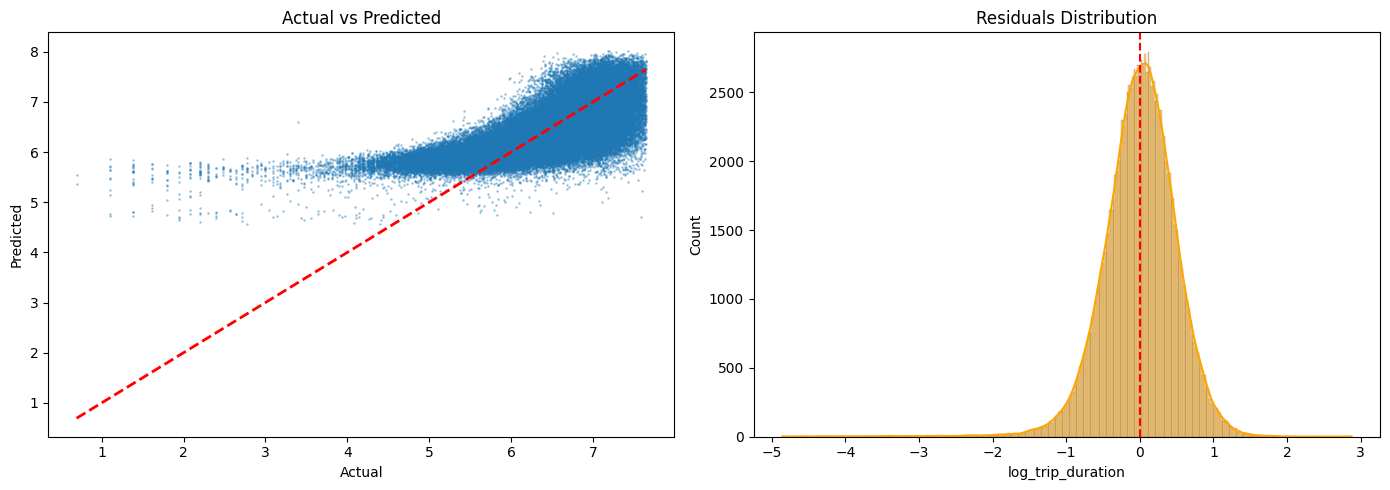

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=1)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residuals Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1],
             color='orange')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()